# Icosahedral Global Graph for Weather-Model-Graphs

This notebook demonstrates the complete pipeline for creating global spherical graphs using icosahedral meshes:

1. **Mesh generation** - Using trimesh to create hierarchical icosahedral meshes
2. **Graph construction** - Building mesh graphs with proper connectivity
3. **Grid-to-mesh connectivity** - Connecting input grid points to mesh nodes
4. **Integration with `create_all_graph_components`** - Using the main API

This approach provides quasi-uniform coverage of the sphere, avoiding the distortion problems of rectilinear grids in latitude/longitude space.

In [1]:
# Install required packages if not already installed
!pip install trimesh matplotlib pyproj networkx

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pyproj

In [2]:
from weather_model_graphs.create.mesh.layouts.icosahedral import (
    generate_icosahedral_mesh,  
    create_hierarchy_of_icosahedral_meshes,
    create_flat_icosahedral_mesh_graph,
    create_hierarchical_icosahedral_mesh_graph,
    connect_grid_to_mesh,
    lat_lon_to_cartesian,
    cartesian_to_lat_lon,
    barycentric_coordinates,
)

from weather_model_graphs.create import create_all_graph_components

## 1. Generate Icosahedral Mesh Hierarchy

First, let's generate a hierarchy of icosahedral meshes at different refinement levels.

In [4]:
# Generate mesh hierarchy
max_subdivisions = 3
mesh_list = create_hierarchy_of_icosahedral_meshes(max_subdivisions)

# Print statistics for each level
print("Icosahedral Mesh Hierarchy:")
print("-" * 50)
for level, (vertices, faces) in enumerate(mesh_list):
    print(f"Level {level}: {len(vertices):4d} nodes, {len(faces):5d} faces")
print("-" * 50)
print(f"Total nodes across all levels: {sum(len(v) for v, _ in mesh_list)}")

Icosahedral Mesh Hierarchy:
--------------------------------------------------
Level 0:   12 nodes,    20 faces
Level 1:   42 nodes,    80 faces
Level 2:  162 nodes,   320 faces
Level 3:  642 nodes,  1280 faces
--------------------------------------------------
Total nodes across all levels: 858


## 2. Create a Sample Global Grid

Let's create a regular latitude/longitude grid to represent our input data.

In [5]:
# Create a 2.5deg resolution global grid
resolution = 2.5
lats = np.arange(-90, 90.1, resolution)
lons = np.arange(-180, 180.1, resolution)
grid_lat, grid_lon = np.meshgrid(lats, lons, indexing='ij')
grid_lat_lon = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])

print(f"Grid resolution: {resolution}deg")
print(f"Grid dimensions: {len(lats)} latitudes x {len(lons)} longitudes")
print(f"Total grid nodes: {len(grid_lat_lon)}")

Grid resolution: 2.5deg
Grid dimensions: 73 latitudes x 145 longitudes
Total grid nodes: 10585


## 3. Connect Grid to Mesh (G2M)

Now connect each grid point to nearby mesh nodes using radius-based search.

In [6]:
max_subdivisions = 3
mesh_list = create_hierarchy_of_icosahedral_meshes(max_subdivisions)

# ADD THIS CHECK HERE - right after generating the mesh
finest_vertices, finest_faces = mesh_list[-1]
print("Checking finest mesh coordinates:")
print(f"Cartesian - X range: [{np.min(finest_vertices[:, 0]):.3f}, {np.max(finest_vertices[:, 0]):.3f}]")
print(f"Cartesian - Y range: [{np.min(finest_vertices[:, 1]):.3f}, {np.max(finest_vertices[:, 1]):.3f}]")
print(f"Cartesian - Z range: [{np.min(finest_vertices[:, 2]):.3f}, {np.max(finest_vertices[:, 2]):.3f}]")

# Convert to lat/lon and check ranges
lat_lon = cartesian_to_lat_lon(finest_vertices)
print(f"Lat range: [{np.min(lat_lon[:, 0]):.1f}, {np.max(lat_lon[:, 0]):.1f}]")
print(f"Lon range: [{np.min(lat_lon[:, 1]):.1f}, {np.max(lat_lon[:, 1]):.1f}]")
print()

# Print statistics for each level
print("Icosahedral Mesh Hierarchy:")
print("-" * 50)
for level, (vertices, faces) in enumerate(mesh_list):
    print(f"Level {level}: {len(vertices):4d} nodes, {len(faces):5d} faces")
print("-" * 50)
print(f"Total nodes across all levels: {sum(len(v) for v, _ in mesh_list)}")

# Connect grid to mesh
g2m_edges = connect_grid_to_mesh(
    grid_lat_lon, 
    finest_vertices, 
    finest_faces,
    radius_factor=0.6  # Connection radius relative to max edge length
)

print(f"Grid-to-mesh connections: {g2m_edges.shape[1]}")
print(f"Average connections per grid node: {g2m_edges.shape[1]/len(grid_lat_lon):.2f}")
print(f"Average connections per mesh node: {g2m_edges.shape[1]/len(finest_vertices):.2f}")

Checking finest mesh coordinates:
Cartesian - X range: [-1.000, 1.000]
Cartesian - Y range: [-1.000, 1.000]
Cartesian - Z range: [-1.000, 1.000]
Lat range: [-90.0, 90.0]
Lon range: [-174.1, 180.0]

Icosahedral Mesh Hierarchy:
--------------------------------------------------
Level 0:   12 nodes,    20 faces
Level 1:   42 nodes,    80 faces
Level 2:  162 nodes,   320 faces
Level 3:  642 nodes,  1280 faces
--------------------------------------------------
Total nodes across all levels: 858
Grid-to-mesh connections: 16617
Average connections per grid node: 1.57
Average connections per mesh node: 25.88


## 4. Create Mesh Graphs

We can create either flat (single-level) or hierarchical (multi-level) mesh graphs.

In [7]:
# Flat mesh graph (single level)
G_flat = create_flat_icosahedral_mesh_graph(subdivisions=3)
print("Flat mesh graph:")
print(f"  Nodes: {len(G_flat.nodes)}")
print(f"  Edges: {len(G_flat.edges)}")
print()

# Hierarchical mesh graph (multiple levels with inter-level connections)
G_hier = create_hierarchical_icosahedral_mesh_graph(max_subdivisions=3)
print("Hierarchical mesh graph:")
print(f"  Total nodes: {len(G_hier.nodes)}")
print(f"  Total edges: {len(G_hier.edges)}")

# Count nodes per level
level_counts = {}
for node, data in G_hier.nodes(data=True):
    level = data.get('level', 0)
    level_counts[level] = level_counts.get(level, 0) + 1

print("\nNodes per level:")
for level in sorted(level_counts.keys()):
    print(f"  Level {level}: {level_counts[level]} nodes")

Flat mesh graph:
  Nodes: 642
  Edges: 3840

Hierarchical mesh graph:
  Total nodes: 858
  Total edges: 8052

Nodes per level:
  Level 0: 12 nodes
  Level 1: 42 nodes
  Level 2: 162 nodes
  Level 3: 642 nodes


## 5. Visualize the Mesh and Connections

Let's visualize the icosahedral mesh and its connections to the grid.

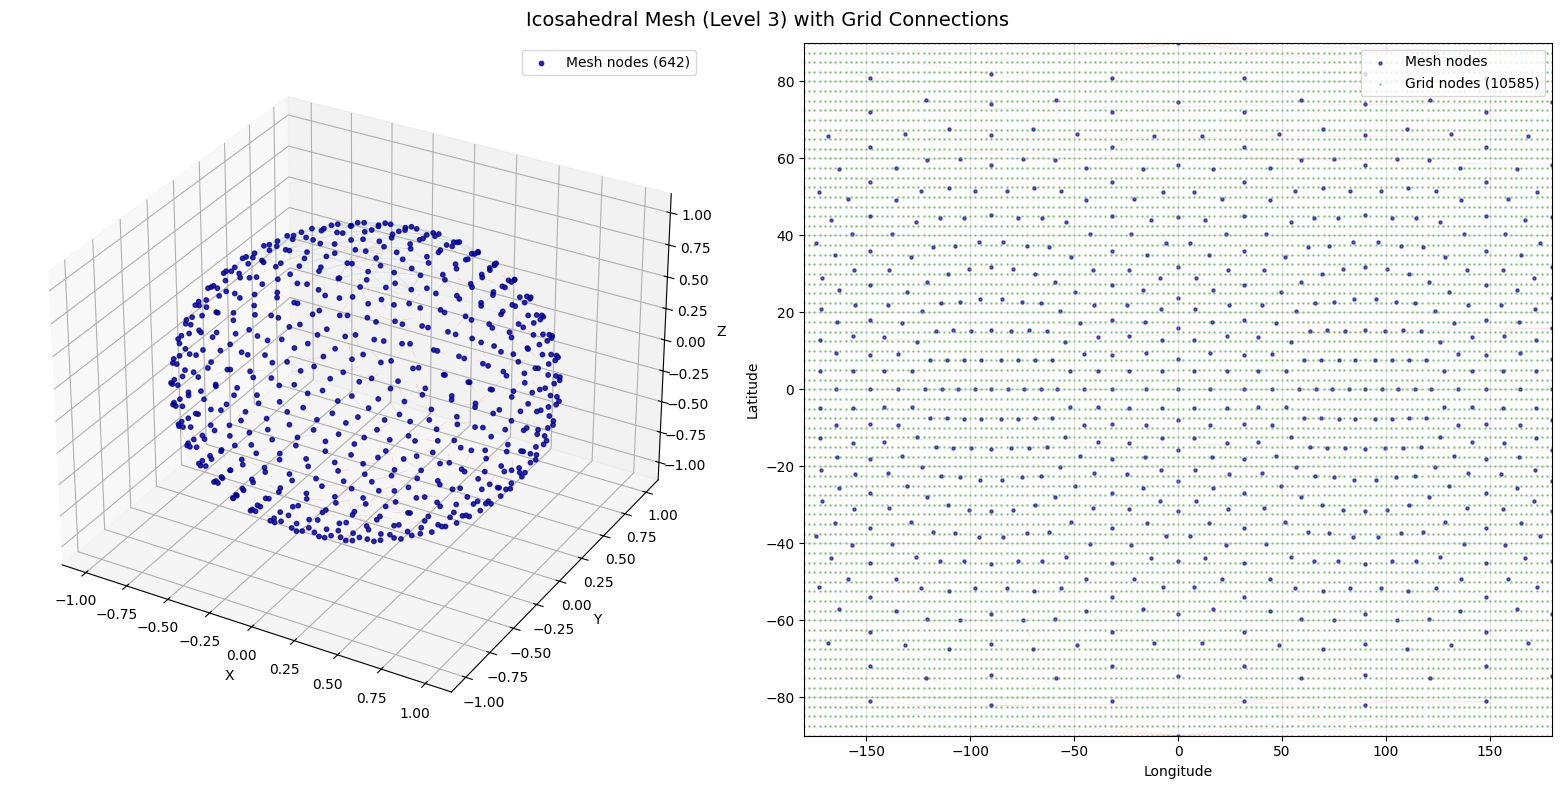

In [8]:
def plot_icosahedral_graph(vertices, faces, g2m_edges=None, grid_lat_lon=None, 
                           title=None, max_edges_to_plot=500):
    """Plot icosahedral mesh with optional grid connections."""
    fig = plt.figure(figsize=(16, 8))
    
    # 3D Plot
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Plot mesh edges
    for face in faces[:100]:  # Plot subset for clarity
        for i, j in [(0,1), (1,2), (2,0)]:
            ax1.plot3D(*zip(vertices[face[i]], vertices[face[j]]), 
                      color='lightblue', alpha=0.3, linewidth=0.5)
    
    # Plot mesh nodes
    ax1.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], 
                c='darkblue', s=10, label=f'Mesh nodes ({len(vertices)})', alpha=0.8)
    
    # Plot grid-to-mesh connections if provided
    if g2m_edges is not None and grid_lat_lon is not None:
        # Sample connections for clarity
        step = max(1, g2m_edges.shape[1] // max_edges_to_plot)
        for i in range(0, g2m_edges.shape[1], step):
            grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
            grid_cart = lat_lon_to_cartesian(
                np.array([grid_lat_lon[grid_idx, 0]]), 
                np.array([grid_lat_lon[grid_idx, 1]])
            )[0]
            ax1.plot3D(*zip(grid_cart, vertices[mesh_idx]), 
                       color='red', alpha=0.2, linewidth=0.3)
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend(loc='upper right')
    
    # 2D Projection
    ax2 = fig.add_subplot(122)
    
    # Convert mesh vertices to lat/lon
    mesh_lat_lon = cartesian_to_lat_lon(vertices)
    
    # Plot mesh nodes
    ax2.scatter(mesh_lat_lon[:, 1], mesh_lat_lon[:, 0], 
                c='darkblue', s=5, label='Mesh nodes', alpha=0.6)
    
    # Plot grid nodes if provided
    if grid_lat_lon is not None:
        ax2.scatter(grid_lat_lon[:, 1], grid_lat_lon[:, 0], 
                    c='green', s=1, label=f'Grid nodes ({len(grid_lat_lon)})', alpha=0.3)
    
    # Plot connections in 2D
    if g2m_edges is not None and grid_lat_lon is not None:
        step = max(1, g2m_edges.shape[1] // max_edges_to_plot)
        for i in range(0, g2m_edges.shape[1], step):
            grid_idx, mesh_idx = g2m_edges[0, i], g2m_edges[1, i]
            grid_lon, grid_lat = grid_lat_lon[grid_idx, 1], grid_lat_lon[grid_idx, 0]
            mesh_lon, mesh_lat = mesh_lat_lon[mesh_idx, 1], mesh_lat_lon[mesh_idx, 0]
            ax2.plot([grid_lon, mesh_lon], [grid_lat, mesh_lat], 
                     color='red', alpha=0.15, linewidth=0.3)
    
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_xlim(-180, 180)
    ax2.set_ylim(-90, 90)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    if title:
        fig.suptitle(title, fontsize=14)
    
    plt.tight_layout()
    return fig, (ax1, ax2)


# Plot the finest mesh with grid connections
fig, axes = plot_icosahedral_graph(
    finest_vertices, 
    finest_faces, 
    g2m_edges, 
    grid_lat_lon,
    title=f"Icosahedral Mesh (Level {max_subdivisions}) with Grid Connections"
)
plt.show()

## 6. Integration with `create_all_graph_components`

Now let's use the main API to create a complete graph with icosahedral mesh.

In [9]:
# Define geographic CRS (WGS84)
geographic_crs = pyproj.CRS.from_string("EPSG:4326")

# Create complete graph with flat icosahedral mesh
G_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "subdivisions": 3,  # Mesh refinement level
        "hierarchical": False,  # Flat mesh (single level)
        "radius": 1.0,  # Sphere radius
    },
    m2g_connectivity="within_radius",
    g2m_connectivity_kwargs={"rel_max_dist": 0.6},
    m2g_connectivity_kwargs={"rel_max_dist": 0.6},
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
    g2m_connectivity="within_radius",        
)

print("Complete graph statistics:")
print(f"  Total nodes: {len(G_complete.nodes)}")
print(f"  Total edges: {len(G_complete.edges)}")

# Count nodes by type
node_types = {}
for node, data in G_complete.nodes(data=True):
    node_type = data.get('type', 'unknown')
    node_types[node_type] = node_types.get(node_type, 0) + 1

print("\nNodes by type:")
for node_type, count in node_types.items():
    print(f"  {node_type}: {count}")

# Count edges by component
edge_components = {}
for u, v, data in G_complete.edges(data=True):
    component = data.get('component', 'unknown')
    edge_components[component] = edge_components.get(component, 0) + 1

print("\nEdges by component:")
for component, count in edge_components.items():
    print(f"  {component}: {count}")


2026-03-01 21:05:26.819 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


query_dist = 0.0988  (longest_edge=0.1646, rel=0.6)
query_dist = 0.0988  (longest_edge=0.1646, rel=0.6)
Complete graph statistics:
  Total nodes: 11227
  Total edges: 37074

Nodes by type:
  mesh: 642
  grid: 10585

Edges by component:
  m2m: 3840
  m2g: 16617
  g2m: 16617


In [10]:
from weather_model_graphs.create.mesh.layouts.icosahedral import generate_icosahedral_mesh
create_icosahedral_mesh = generate_icosahedral_mesh

# Then run the hierarchical example
G_hier_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "max_subdivisions": 3,
        "hierarchical": True,
        "radius": 1.0,
    },
    m2g_connectivity="within_radius",
    g2m_connectivity="within_radius",
    m2g_connectivity_kwargs={"rel_max_dist": 0.6},
    g2m_connectivity_kwargs={"rel_max_dist": 0.6},
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
    return_components=True
)
m2m = G_hier_complete["m2m"]
edge_levels = set(d.get("level") for _, _, d in m2m.edges(data=True))
print("Edge levels found:", edge_levels)

lens = [d["len"] for _, _, d in m2m.edges(data=True) if "len" in d]
print(f"Min len: {min(lens):.4f}, Max len: {max(lens):.4f}, Mean: {sum(lens)/len(lens):.4f}")


2026-03-01 21:05:30.161 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


query_dist = 0.6309  (longest_edge=1.0515, rel=0.6)
query_dist = 0.6309  (longest_edge=1.0515, rel=0.6)
Edge levels found: {0, 1, '2_to_1', 3, 2, '3_to_2', '1_to_2', '0_to_1', '1_to_0', '2_to_3'}
Min len: 0.0000, Max len: 1.0515, Mean: 0.1942


## 7. Hierarchical Mesh Example

Create a graph with hierarchical (multi-level) icosahedral mesh.

In [11]:
# Create hierarchical graph with multiple mesh levels
G_hier_complete = create_all_graph_components(
    coords=grid_lat_lon,
    m2m_connectivity="icosahedral",
    m2m_connectivity_kwargs={
        "max_subdivisions": 3,  # Maximum refinement level
        "hierarchical": True,  # Enable hierarchy
        "radius": 1.0,
    },
    m2g_connectivity="within_radius",
    m2g_connectivity_kwargs={
        "max_dist": 0.5,
    },
    g2m_connectivity="within_radius",
    g2m_connectivity_kwargs={
        "max_dist": 0.5,
    },
    coords_crs=geographic_crs,
    graph_crs=geographic_crs,
)

print("Hierarchical graph statistics:")
print(f"  Total nodes: {len(G_hier_complete.nodes)}")
print(f"  Total edges: {len(G_hier_complete.edges)}")

# Count mesh nodes by level
mesh_levels = {}
for node, data in G_hier_complete.nodes(data=True):
    if data.get('type') == 'mesh':
        level = data.get('level', 0)
        mesh_levels[level] = mesh_levels.get(level, 0) + 1

print("\nMesh nodes by level:")
for level in sorted(mesh_levels.keys()):
    print(f"  Level {level}: {mesh_levels[level]} nodes")

2026-03-01 21:05:32.484 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:118 - Projecting coords from CRS(EPSG:4326) to CRS(EPSG:4326) for graph creation.


Hierarchical graph statistics:
  Total nodes: 11443
  Total edges: 22984

Mesh nodes by level:
  Level 0: 12 nodes
  Level 1: 42 nodes
  Level 2: 162 nodes
  Level 3: 642 nodes


## 8. Visualize Graph Components

Let's visualize the different components of our graph.

Plotting graph components...
Plotted 3840 edges for component 'm2m'

Mesh node distribution for component 'm2m':
  Longitude range: [-174.1, 180.0]
  Latitude range: [-90.0, 90.0]


C:\Users\Admin\AppData\Local\Temp\ipykernel_4292\3875406905.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


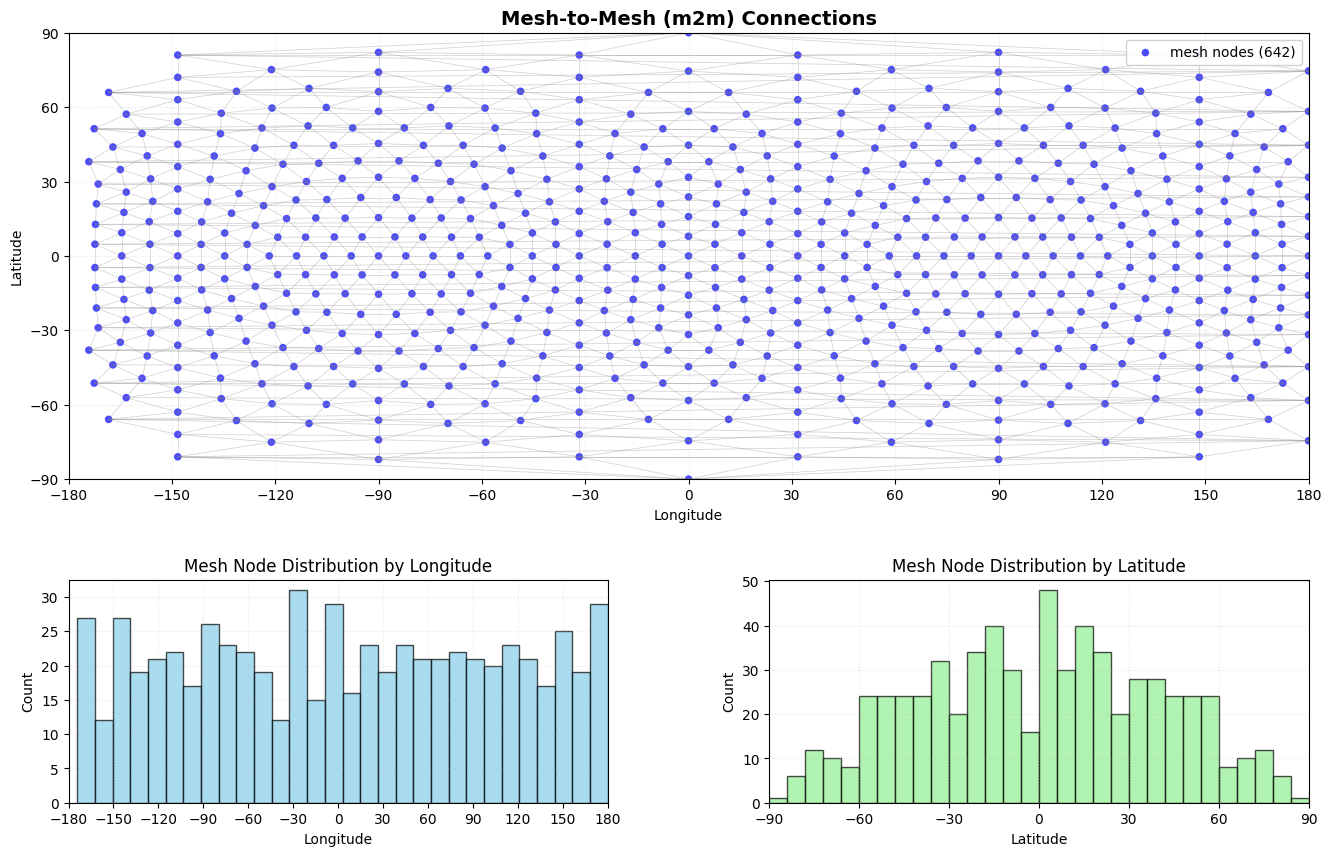

Plotted 16617 edges for component 'g2m'


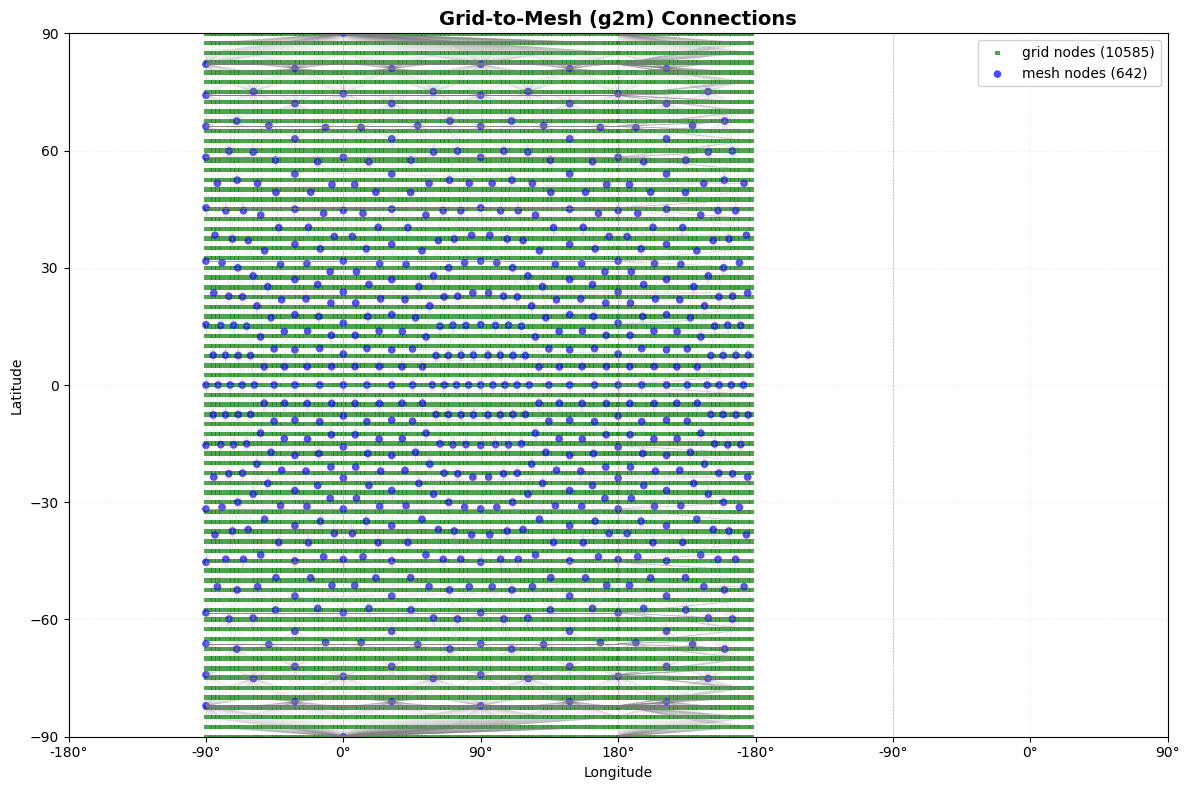

Plotted 16617 edges for component 'm2g'


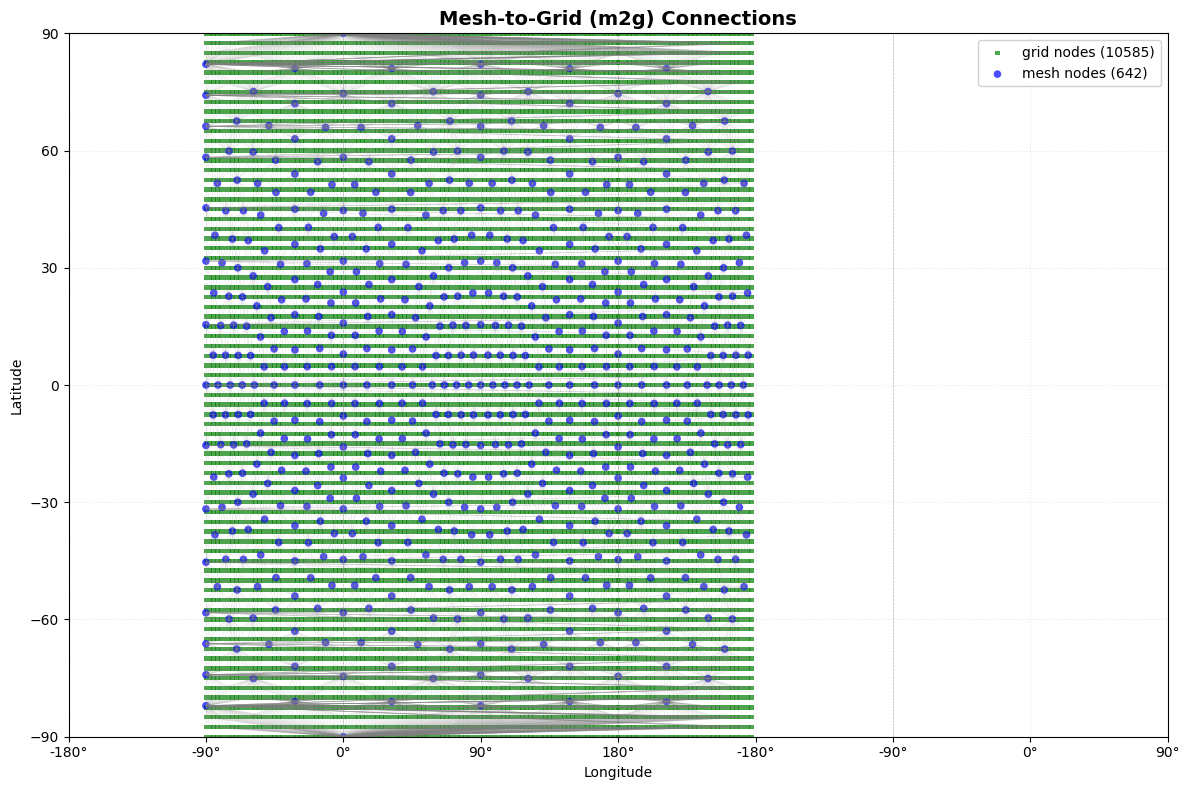

In [ ]:
def plot_graph_component(G, component_name, title=None, shift_antimeridian=True, 
                         show_distribution=False):
    # Extract subgraph for this component
    edges = [(u, v) for u, v, d in G.edges(data=True) 
             if d.get('component') == component_name]
    
    if not edges:
        print(f"No edges found for component '{component_name}'")
        return
    
    G_sub = G.edge_subgraph(edges).copy()
    
    # Collect positions for plotting
    pos_2d = {}
    node_types = {}
    
    # Also collect mesh node positions separately for distribution analysis
    mesh_lons = []
    mesh_lats = []
    
    for node in G_sub.nodes:
        data = G.nodes[node]
        
        if 'pos3d' in data and data['pos3d'] is not None:
            # Convert 3D cartesian to lat/lon
            pos3d = data['pos3d']
            if isinstance(pos3d, (list, np.ndarray)) and len(pos3d) == 3:
                lat_lon = cartesian_to_lat_lon(np.array(pos3d).reshape(1, 3))[0]
                lon, lat = lat_lon[1], lat_lon[0]
            else:
                # Fallback to pos if conversion fails
                if 'pos' in data and data['pos'] is not None:
                    pos = data['pos']
                    if len(pos) == 2:
                        lat, lon = pos[0], pos[1]
                    else:
                        continue
                else:
                    continue
        elif 'pos' in data and data['pos'] is not None:
            pos = data['pos']
            if len(pos) == 2:
                lat, lon = pos[0], pos[1]
            elif len(pos) == 3:
                # Try to interpret as lat/lon/altitude
                lat, lon = pos[0], pos[1]
            else:
                continue
        elif 'lat' in data and 'lon' in data:
            lat, lon = data['lat'], data['lon']
        else:
            continue
        
        node_type = data.get('type', 'unknown')
        if node_type == 'mesh':
            mesh_lons.append(lon)
            mesh_lats.append(lat)
        
        if shift_antimeridian and lon < -90:
            lon += 360
            
        pos_2d[node] = (lon, lat)
        node_types[node] = node_type
    
    if not pos_2d:
        print(f"No valid position data found for nodes in component '{component_name}'")
        return
    
    if show_distribution and mesh_lons:
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.3)
        
        # Main plot
        ax_main = fig.add_subplot(gs[0, :])
        
        # Distribution plots
        ax_lon = fig.add_subplot(gs[1, 0])
        ax_lat = fig.add_subplot(gs[1, 1])
    else:
        fig, ax_main = plt.subplots(figsize=(12, 8))
    
    edge_count = 0
    for u, v in G_sub.edges():
        if u in pos_2d and v in pos_2d:
            x_coords = [pos_2d[u][0], pos_2d[v][0]]
            y_coords = [pos_2d[u][1], pos_2d[v][1]]
            
            if shift_antimeridian:
                if abs(x_coords[0] - x_coords[1]) > 180:
                    # Split the edge into two segments
                    x_mid = 180 if max(x_coords) > 180 else -180
                    y_mid1 = np.interp(x_mid, x_coords, y_coords)
                    y_mid2 = y_mid1
                    
                    # Plot first segment
                    ax_main.plot([x_coords[0], x_mid], [y_coords[0], y_mid1], 
                                'gray', alpha=0.2, linewidth=0.5)
                    # Plot second segment
                    ax_main.plot([x_mid, x_coords[1]], [y_mid2, y_coords[1]], 
                                'gray', alpha=0.2, linewidth=0.5)
                else:
                    ax_main.plot(x_coords, y_coords, 'gray', alpha=0.2, linewidth=0.5)
            else:
                ax_main.plot(x_coords, y_coords, 'gray', alpha=0.2, linewidth=0.5)
            edge_count += 1
    
    print(f"Plotted {edge_count} edges for component '{component_name}'")
    
    colors = {'mesh': 'blue', 'grid': 'green', 'unknown': 'red'}
    markers = {'mesh': 'o', 'grid': 's', 'unknown': '^'}
    sizes = {'mesh': 30, 'grid': 10, 'unknown': 20}
    
    for node_type in set(node_types.values()):
        nodes = [n for n in G_sub.nodes if node_types[n] == node_type]
        if nodes:
            x = [pos_2d[n][0] for n in nodes]
            y = [pos_2d[n][1] for n in nodes]
            
            scatter = ax_main.scatter(x, y, 
                                     c=colors.get(node_type, 'black'),
                                     marker=markers.get(node_type, 'o'),
                                     s=sizes.get(node_type, 20),
                                     label=f'{node_type} nodes ({len(nodes)})',
                                     alpha=0.7, edgecolors='none')
    
    if shift_antimeridian:
        ax_main.set_xlim(-180, 540)  # Show from -180 to +180 (shifted to 540)
        ax_main.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)
        ax_main.axvline(x=180, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)
        ax_main.axvline(x=360, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)
        
        # Custom ticks for shifted coordinates
        ax_main.set_xticks([-180, -90, 0, 90, 180, 270, 360, 450, 540])
        ax_main.set_xticklabels(['-180°', '-90°', '0°', '90°', '180°', 
                                 '-180°', '-90°', '0°', '90°'])
    else:
        ax_main.set_xlim(-180, 180)
        ax_main.set_xticks(np.arange(-180, 181, 30))
    
    ax_main.set_ylim(-90, 90)
    ax_main.set_yticks(np.arange(-90, 91, 30))
    
    ax_main.set_xlabel('Longitude')
    ax_main.set_ylabel('Latitude')
    ax_main.grid(True, alpha=0.3, linestyle=':')
    
    ax_main.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    if title:
        ax_main.set_title(title, fontsize=14, fontweight='bold')
    else:
        ax_main.set_title(f"Graph Component: {component_name}", fontsize=14, fontweight='bold')
    
    if show_distribution and mesh_lons:
        # Print distribution statistics
        print(f"\nMesh node distribution for component '{component_name}':")
        print(f"  Longitude range: [{min(mesh_lons):.1f}, {max(mesh_lons):.1f}]")
        print(f"  Latitude range: [{min(mesh_lats):.1f}, {max(mesh_lats):.1f}]")
        
        ax_lon.hist(mesh_lons, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
        ax_lon.set_xlabel('Longitude')
        ax_lon.set_ylabel('Count')
        ax_lon.set_title('Mesh Node Distribution by Longitude')
        ax_lon.grid(True, alpha=0.3, linestyle=':')
        
        if shift_antimeridian:
            ax_lon.set_xlim(-180, 540)
            ax_lon.set_xticks([-180, -90, 0, 90, 180, 270, 360, 450, 540])
            ax_lon.set_xticklabels(['-180°', '-90°', '0°', '90°', '180°', 
                                    '-180°', '-90°', '0°', '90°'], rotation=45)
        else:
            ax_lon.set_xlim(-180, 180)
            ax_lon.set_xticks(np.arange(-180, 181, 30))
        
        # Latitude histogram
        ax_lat.hist(mesh_lats, bins=30, edgecolor='black', color='lightgreen', alpha=0.7)
        ax_lat.set_xlabel('Latitude')
        ax_lat.set_ylabel('Count')
        ax_lat.set_title('Mesh Node Distribution by Latitude')
        ax_lat.set_xlim(-90, 90)
        ax_lat.set_xticks(np.arange(-90, 91, 30))
        ax_lat.grid(True, alpha=0.3, linestyle=':')
    
    plt.tight_layout()
    return fig, ax_main if not show_distribution else fig


print("Plotting graph components...")

# Plot m2m (mesh-to-mesh) without shifting to see original distribution
# Also show distribution to verify mesh node coverage
fig, ax = plot_graph_component(G_complete, 'm2m', 
                               title="Mesh-to-Mesh (m2m) Connections",
                               shift_antimeridian=False,
                               show_distribution=True)
plt.show()

# Plot g2m (grid-to-mesh) with shifting to see full connectivity
fig, ax = plot_graph_component(G_complete, 'g2m',
                               title="Grid-to-Mesh (g2m) Connections",
                               shift_antimeridian=True,
                               show_distribution=False)
plt.show()

# Plot m2g (mesh-to-grid) with shifting to see full connectivity
fig, ax = plot_graph_component(G_complete, 'm2g',
                               title="Mesh-to-Grid (m2g) Connections",
                               shift_antimeridian=True,
                               show_distribution=False)
plt.show()

## 9. Performance and Scaling

Let's examine how the mesh size scales with subdivision level.

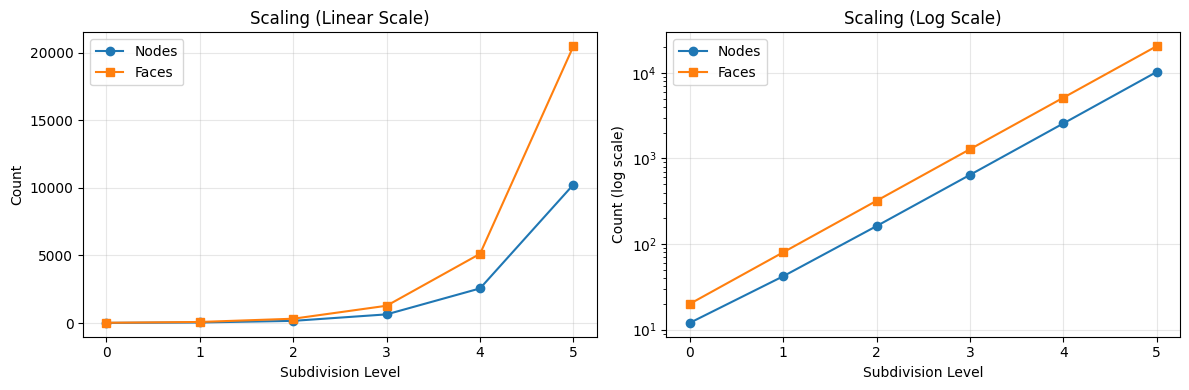


Growth rate:
Level 0 -> 1: 3.50x (theoretical: 4x)
Level 1 -> 2: 3.86x (theoretical: 4x)
Level 2 -> 3: 3.96x (theoretical: 4x)
Level 3 -> 4: 3.99x (theoretical: 4x)
Level 4 -> 5: 4.00x (theoretical: 4x)


In [13]:
# Analyze scaling behavior
subdivisions = np.arange(0, 6)
node_counts = []
face_counts = []

for s in subdivisions:
    v, f = generate_icosahedral_mesh(refinement_level=s)
    node_counts.append(len(v))
    face_counts.append(len(f))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax1.plot(subdivisions, node_counts, 'o-', label='Nodes')
ax1.plot(subdivisions, face_counts, 's-', label='Faces')
ax1.set_xlabel('Subdivision Level')
ax1.set_ylabel('Count')
ax1.set_title('Scaling (Linear Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(subdivisions, node_counts, 'o-', label='Nodes')
ax2.semilogy(subdivisions, face_counts, 's-', label='Faces')
ax2.set_xlabel('Subdivision Level')
ax2.set_ylabel('Count (log scale)')
ax2.set_title('Scaling (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGrowth rate:")
for i in range(1, len(subdivisions)):
    ratio = node_counts[i] / node_counts[i-1]
    print(f"Level {i-1} -> {i}: {ratio:.2f}x (theoretical: 4x)")

## 10. Face-Adjacent Connectivity

Every node connects to exactly 5 or 6 face-adjacent neighbours — 5 at the 12 original icosahedron vertices, 6 everywhere else. Connectivity is fully determined by the triangulation faces, no pattern kwarg needed.

In [4]:
import plotly.graph_objects as go

vertices, faces = generate_icosahedral_mesh(refinement_level=1)
lat_lon = cartesian_to_lat_lon(vertices)
lat, lon = lat_lon[:, 0], lat_lon[:, 1]

edges = set()
for f in faces:
    for i, j in [(0,1),(1,2),(2,0)]:
        edges.add((min(f[i],f[j]), max(f[i],f[j])))

degree = np.zeros(len(vertices), dtype=int)
for e in edges:
    degree[e[0]] += 1
    degree[e[1]] += 1

edge_lons, edge_lats = [], []
for e in edges:
    lo = [lon[e[0]], lon[e[1]]]
    la = [lat[e[0]], lat[e[1]]]
    if abs(lo[1] - lo[0]) < 180:
        edge_lons += [lo[0], lo[1], None]
        edge_lats += [la[0], la[1], None]

highlight_idx = next(i for i in range(len(vertices)) if degree[i]==6 and abs(lat[i]) < 20)
neighbours = [e[1] if e[0]==highlight_idx else e[0] for e in edges if highlight_idx in e]

hl_lons, hl_lats = [], []
for n in neighbours:
    if abs(lon[n] - lon[highlight_idx]) < 180:
        hl_lons += [lon[highlight_idx], lon[n], None]
        hl_lats += [lat[highlight_idx], lat[n], None]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=edge_lons, y=edge_lats, mode='lines',
    line=dict(color='steelblue', width=1), opacity=0.5,
    name='Face-adjacent edge', hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=lon[degree==6], y=lat[degree==6], mode='markers',
    marker=dict(size=9, color='cornflowerblue', line=dict(color='white', width=1)),
    name='6 neighbours (regular)'
))
fig.add_trace(go.Scatter(
    x=lon[degree==5], y=lat[degree==5], mode='markers',
    marker=dict(size=9, color='tomato', line=dict(color='white', width=1)),
    name='5 neighbours (icosahedral vertex)'
))
fig.add_trace(go.Scatter(
    x=hl_lons, y=hl_lats, mode='lines',
    line=dict(color='gold', width=3),
    name=f'Example node: {degree[highlight_idx]} face-adjacent neighbours',
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=[lon[highlight_idx]], y=[lat[highlight_idx]], mode='markers',
    marker=dict(size=15, color='gold', line=dict(color='black', width=2)),
    name='Example node'
))
fig.update_layout(
    title='Icosahedral Mesh - Face-adjacent Connectivity (Refinement Level 1)',
    xaxis_title='Longitude', yaxis_title='Latitude',
    xaxis=dict(range=[-185, 185]),
    yaxis=dict(range=[-95, 95]),
    width=1100, height=620,
)
fig.show()

## 11. Containing Triangle M2G

Each grid point connects to the 3 vertices of its containing mesh triangle. Edge weights are barycentric coordinates — they sum to 1 and line thickness is proportional to weight.

In [5]:
from scipy.spatial import cKDTree

vertices, faces = generate_icosahedral_mesh(refinement_level=2)
lat_lon = cartesian_to_lat_lon(vertices)
lat, lon = lat_lon[:, 0], lat_lon[:, 1]

target_lat, target_lon = 20.0, 10.0
target_xyz = lat_lon_to_cartesian(np.array([target_lat]), np.array([target_lon]))

face_centroids = vertices[faces].mean(axis=1)
face_centroids /= np.linalg.norm(face_centroids, axis=1, keepdims=True)
tree = cKDTree(face_centroids)

_, near = tree.query(target_xyz, k=8)
containing_face, bary = None, None
for fi in near[0]:
    v1, v2, v3 = faces[fi]
    w = barycentric_coordinates(target_xyz[0], vertices[v1], vertices[v2], vertices[v3])
    if w is not None and w.min() >= -1e-6:
        containing_face, bary = fi, w / w.sum()
        break

if containing_face is None:
    containing_face = near[0][0]
    v1, v2, v3 = faces[containing_face]
    bary = barycentric_coordinates(target_xyz[0], vertices[v1], vertices[v2], vertices[v3])
    bary = np.clip(bary, 0, None); bary /= bary.sum()

tri_verts = list(faces[containing_face])
tri_lats, tri_lons = lat[tri_verts], lon[tri_verts]

_, nearby_faces = tree.query(face_centroids[containing_face:containing_face+1], k=7)
context_nodes = set()
for fi in nearby_faces[0]:
    for ni in faces[fi]: context_nodes.add(ni)
context_nodes -= set(tri_verts)

fig = go.Figure()
for fi in nearby_faces[0]:
    if fi == containing_face: continue
    fv = faces[fi]
    flats, flons = lat[fv], lon[fv]
    if np.max(flons) - np.min(flons) > 90: continue
    fig.add_trace(go.Scatter(
        x=list(flons)+[flons[0]], y=list(flats)+[flats[0]],
        mode='lines', line=dict(color='lightsteelblue', width=1),
        opacity=0.6, showlegend=False, hoverinfo='skip'
    ))

fig.add_trace(go.Scatter(
    x=list(tri_lons)+[tri_lons[0]], y=list(tri_lats)+[tri_lats[0]],
    mode='lines', fill='toself', fillcolor='rgba(100,149,237,0.15)',
    line=dict(color='cornflowerblue', width=2.5), name='Containing triangle'
))
for vi, (node_idx, w) in enumerate(zip(tri_verts, bary)):
    fig.add_trace(go.Scatter(
        x=[target_lon, lon[node_idx]], y=[target_lat, lat[node_idx]],
        mode='lines', line=dict(color='tomato', width=1.5 + 5.0*float(w)),
        name=f'w{vi+1} = {w:.3f}'
    ))
fig.add_trace(go.Scatter(
    x=lon[list(context_nodes)], y=lat[list(context_nodes)], mode='markers',
    marker=dict(size=7, color='lightsteelblue', line=dict(color='white', width=1)),
    name='Other mesh nodes'
))
fig.add_trace(go.Scatter(
    x=tri_lons, y=tri_lats, mode='markers+text',
    marker=dict(size=14, color='cornflowerblue', line=dict(color='white', width=2)),
    text=[f'v1 (w={bary[0]:.3f})', f'v2 (w={bary[1]:.3f})', f'v3 (w={bary[2]:.3f})'],
    textposition=['top left', 'top right', 'bottom center'],
    textfont=dict(size=12), name='Triangle vertices'
))
fig.add_trace(go.Scatter(
    x=[target_lon], y=[target_lat], mode='markers+text',
    marker=dict(size=14, color='tomato', symbol='square', line=dict(color='black', width=2)),
    text=['Grid point'], textposition='middle right',
    name='Grid point'
))
pad = 12
fig.update_layout(
    title='Containing Triangle M2G - Single Grid Point',
    xaxis_title='Longitude', yaxis_title='Latitude',
    xaxis=dict(range=[target_lon-pad, target_lon+pad]),
    yaxis=dict(range=[target_lat-pad, target_lat+pad]),
    width=800, height=700,
)

## 12. Save and Load Graph

Finally, let's save our graph for later use.

In [ ]:
import pickle
import os

# Create directory for saving graphs
os.makedirs('saved_graphs', exist_ok=True)

# Save the complete graph
with open('saved_graphs/icosahedral_graph.pkl', 'wb') as f:
    pickle.dump(G_complete, f)

print("Graph saved to 'saved_graphs/icosahedral_graph.pkl'")

# Load it back
with open('saved_graphs/icosahedral_graph.pkl', 'rb') as f:
    G_loaded = pickle.load(f)

print(f"\nLoaded graph: {len(G_loaded.nodes)} nodes, {len(G_loaded.edges)} edges")

Graph saved to 'saved_graphs/icosahedral_graph.pkl'

Loaded graph: 11227 nodes, 37074 edges
